<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning - 2301CS621</b></center>

<center><b><h1>Lab - 12 </b></center>
<pre>    

## **Name :** Krish V. Gohel
### **Enrollment No :** 22010101060
### **Roll No :** 188
### **Batch :** A5

# Multilayer Perceptron (MLP) on MNIST and CIFAR-10


**Steps:**
1. Load and preprocess the datasets
2. Build an MLP model
3. Train the model
4. Evaluate the model


## Understanding the Datasets
Before we start training a model, let's understand the datasets:
- **MNIST**: 28x28 grayscale images of handwritten digits (0-9)
- **CIFAR-10**: 32x32 color images belonging to 10 different classes

We will process each dataset step by step and train a Multilayer Perceptron (MLP) model.

In [2]:
#pip install tensorflow

In [3]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

### Step 1: Load the MNIST Dataset
TensorFlow provides built-in datasets, including MNIST, which we can load directly.

In [4]:
(X_train,y_train),(X_test,y_test) = keras.datasets.mnist.load_data()

In [5]:
X_test.shape

(10000, 28, 28)

In [6]:
X_train.shape

(60000, 28, 28)

In [7]:
y_test.shape

(10000,)

In [8]:
y_train.shape

(60000,)

In [9]:
X_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

### Step 2: Preprocess MNIST
To prepare the data for training, we need to:
- Normalize pixel values (scale between 0 and 1)
- Flatten images from 28x28 matrices to 784-length vectors
- Display a few sample images to understand the dataset

In [10]:
X_train,X_test = X_train/255.0, X_test/255.0

X_train = X_train.reshape(-1,28*28)
X_test = X_test.reshape(-1,28*28)

In [11]:
X_train.shape

(60000, 784)

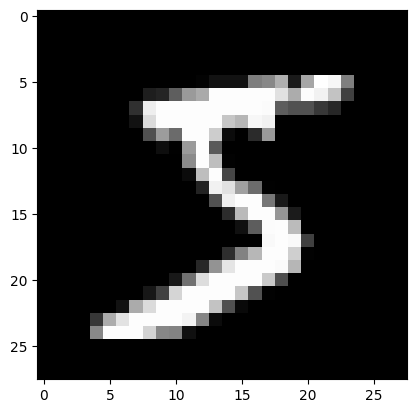

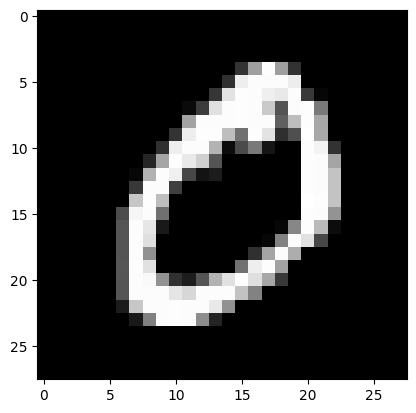

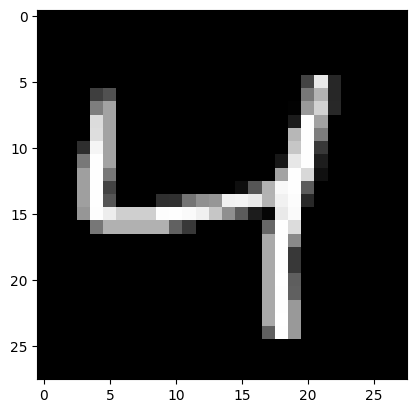

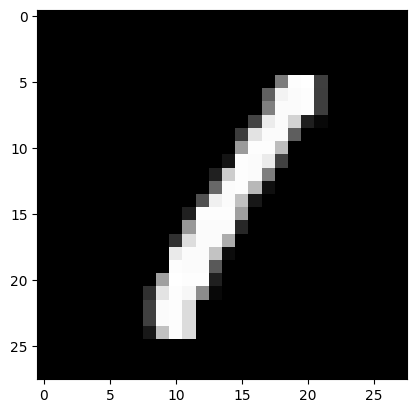

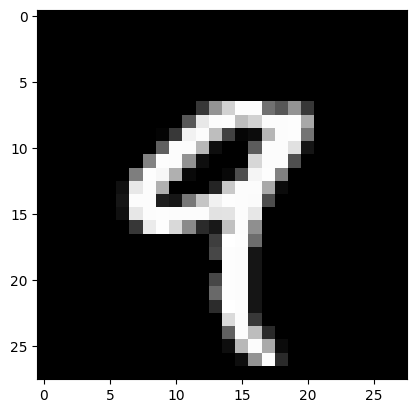

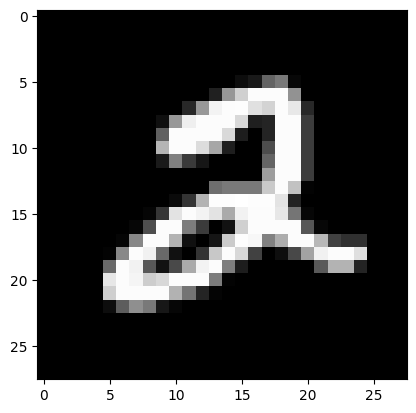

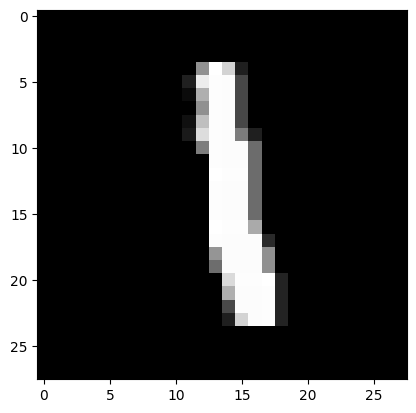

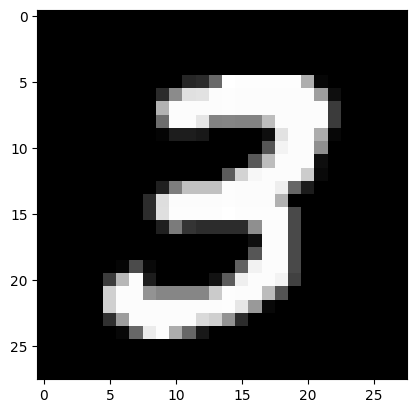

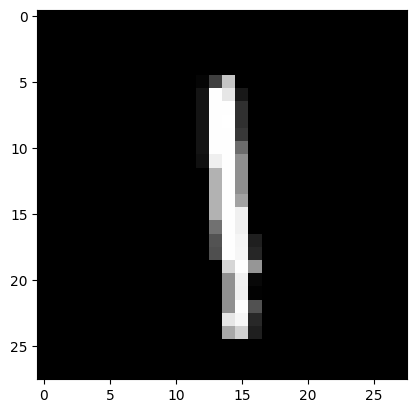

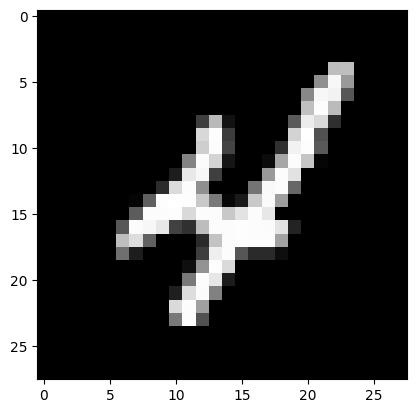

In [12]:
for i in range(0,10):
  plt.imshow(X_train[i].reshape(28,28),cmap='gray')
  plt.show()


### Step 3: Define MLP Architecture
An MLP consists of fully connected layers. For MNIST, we use:
- **Input Layer**: 784 neurons (one per pixel)
- **Hidden Layer 1**: 128 neurons, ReLU activation
- **Hidden Layer 2**: 64 neurons, ReLU activation
- **Output Layer**: 10 neurons (one per digit), Softmax activation

In [13]:
model_mnist = keras.models.Sequential([
    keras.layers.Dense(128,activation = 'relu' , input_shape=(28*28,)),
    keras.layers.Dense(64,activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model_mnist.compile(optimizer='adam',loss = 'sparse_categorical_crossentropy',metrics=['accuracy'])

### Step 4: Train the MNIST Model
Train the model using the `.fit()` function, specifying training data, epochs, and validation data.

In [15]:
model_mnist.fit(X_train,y_train,epochs = 25, validation_data=(X_test,y_test))

Epoch 1/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8776 - loss: 0.4197 - val_accuracy: 0.9593 - val_loss: 0.1347
Epoch 2/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9669 - loss: 0.1085 - val_accuracy: 0.9696 - val_loss: 0.0919
Epoch 3/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9772 - loss: 0.0711 - val_accuracy: 0.9712 - val_loss: 0.0931
Epoch 4/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9836 - loss: 0.0484 - val_accuracy: 0.9746 - val_loss: 0.0851
Epoch 5/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9872 - loss: 0.0398 - val_accuracy: 0.9731 - val_loss: 0.0879
Epoch 6/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9892 - loss: 0.0329 - val_accuracy: 0.9763 - val_loss: 0.0801
Epoch 7/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9907 - loss: 0.0269 - val_accuracy: 0.9781 - val_loss: 0.0740
Epoch 8/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9924 - loss: 0.0231 -

### Step 5: Evaluate the MNIST Model

In [16]:
test_loss,test_acc = model_mnist.evaluate(X_test,y_test)
print(f'accuracy : {test_acc:.4f} \nloss : {test_loss:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9711 - loss: 0.1799
accuracy : 0.9762 
loss : 0.1476


In [17]:
y_pred = model_mnist.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [18]:
y_pred[9999].argmax()

6

### Step 4.1: print Model summary()

In [19]:
model_mnist.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 328,160 (1.25 MB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 218,774 (854.59 KB)

In [20]:
for layer in model_mnist.layers:
  weights, biases = layer.get_weights()
  print(f"Weights : {weights}")
  print(f"Biases : {biases}")

Weights : [[-0.04978063 -0.06768513  0.0050547  ...  0.01812202  0.03390304
  -0.01142021]
 [-0.01729635 -0.06050643  0.07165746 ...  0.07345933 -0.07174323
   0.0390969 ]
 [-0.04206163  0.07010192  0.02373442 ...  0.06440441 -0.00427818
   0.01767503]
 ...
 [ 0.05019508  0.07187561 -0.02606728 ... -0.02962508  0.07683458
   0.04730649]
 [ 0.05820458  0.04995456 -0.03845976 ... -0.03040518 -0.01219314
   0.00074911]
 [-0.02219584 -0.00429618 -0.06437598 ...  0.05889758  0.07371572
   0.02758908]]
Biases : [-0.07486541  0.16034949  0.04784121 -0.04998051 -0.10008918 -0.12814406
 -0.06715152  0.20161556  0.00450418  0.04754211 -0.10677466 -0.09296314
 -0.13973378  0.09503999 -0.05755709  0.2554635   0.02180565  0.09794156
  0.06973701  0.03099068 -0.09771138  0.09859086 -0.0120157  -0.08600035
 -0.02871818  0.27189595 -0.20028974 -0.16035543  0.30281845  0.06075833
  0.11939448  0.0673139  -0.11907677  0.21786942 -0.2067957   0.0189243
  0.20223175 -0.17670223  0.17026281 -0.08508802  0.

# Repeat Steps for CIFAR-10

In [21]:
(X_train1,y_train1),(X_test1,y_test1) = keras.datasets.cifar10.load_data()

In [22]:
X_train1.shape

(50000, 32, 32, 3)

In [23]:
X_test1.shape

(10000, 32, 32, 3)

In [24]:
X_train1,X_test1 = X_train1/255.0,X_test1/255.0

X_train1 = X_train1.reshape(-1,32*32*3)
X_test1 = X_test1.reshape(-1,32*32*3)

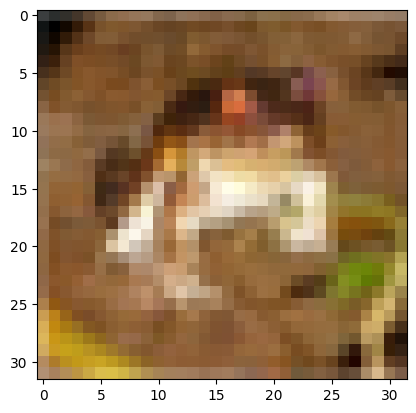

In [25]:
plt.imshow(X_train1[0].reshape(32,32,3),cmap='gray')
plt.show()

In [26]:
model_mnist_1 = keras.models.Sequential([
    keras.layers.Dense(128,activation = 'relu' , input_shape=(32*32*3,)),
    keras.layers.Dense(64,activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

In [27]:
model_mnist_1.compile(optimizer='adam',loss = 'sparse_categorical_crossentropy',metrics=['accuracy'])

In [28]:
model_mnist_1.fit(X_train1,y_train1,epochs = 25, validation_data=(X_test1,y_test1))

Epoch 1/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.2697 - loss: 2.0080 - val_accuracy: 0.3900 - val_loss: 1.7210
Epoch 2/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.3858 - loss: 1.7183 - val_accuracy: 0.3909 - val_loss: 1.7033
Epoch 3/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.4158 - loss: 1.6251 - val_accuracy: 0.4225 - val_loss: 1.6096
Epoch 4/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.4317 - loss: 1.5882 - val_accuracy: 0.4293 - val_loss: 1.5988
Epoch 5/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.4397 - loss: 1.5652 - val_accuracy: 0.4471 - val_loss: 1.5426
Epoch 6/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.4495 - loss: 1.5404 - val_accuracy: 0.4406 - val_loss: 1.5572
Epoch 7/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.4599 - loss: 1.5128 - val_accuracy: 0.4517 - val_loss: 1.5406
Epoch 8/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.4636 - loss: 1

In [29]:
test_loss,test_acc = model_mnist_1.evaluate(X_test1,y_test1)
print(f'accuracy : {test_acc:.4f} \nloss : {test_loss:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4967 - loss: 1.4403
accuracy : 0.4858 
loss : 1.4546


In [30]:
y_pred1 = model_mnist_1.predict(X_test1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [31]:
y_pred1[9999].argmax()

7

In [32]:
model_mnist_1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 128)                 │         393,344 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,206,752 (4.60 MB)

 Trainable params: 402,250 (1.53 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 804,502 (3.07 MB)

In [33]:
for layer in model_mnist_1.layers:
  weights, biases = layer.get_weights()
  print(f"Weights : {weights}")
  print(f"Biases : {biases}")

Weights : [[-1.50622474e-02 -3.38420682e-02  2.64046311e-01 ... -2.46570725e-02
  -3.30617954e-03  8.27464089e-03]
 [-2.57096943e-02 -3.95448208e-02  3.48630488e-01 ...  1.57247614e-02
   2.60848515e-02  3.78553420e-02]
 [-2.08876319e-02  4.06813920e-02  3.43418121e-02 ... -4.36552195e-03
  -1.87904723e-02  2.12961752e-02]
 ...
 [-2.01275069e-02 -2.63512023e-02  1.92423359e-01 ... -3.22049186e-02
   2.85821389e-02  2.54321285e-02]
 [-3.93404625e-02  1.89010445e-02  1.36017665e-01 ...  2.15919642e-03
  -1.18575487e-02 -1.84526742e-02]
 [ 3.25450152e-02 -1.02175836e-04  3.51325601e-01 ... -5.54685155e-03
   1.60015970e-02 -1.64247379e-02]]
Biases : [-5.99940028e-03 -2.61115702e-03 -6.04384363e-01 -5.99645870e-03
 -4.40539652e-03 -5.88986138e-03 -6.00142777e-03 -7.75524834e-03
 -6.00487040e-03 -6.28686836e-03 -5.78280678e-03 -3.51190730e-03
 -6.11439254e-03  2.17078716e-01 -4.91134217e-03 -1.91926048e-03
 -6.00480195e-03 -7.17939867e-04 -5.98997483e-03 -6.00270461e-03
 -3.36730570e-01 -6.

# Repeat Steps for CIFAR-100

In [34]:
(X_train2,y_train2),(X_test2,y_test2) = keras.datasets.cifar100.load_data()

In [35]:
X_train2.shape

(50000, 32, 32, 3)

In [36]:
X_test2.shape

(10000, 32, 32, 3)

In [37]:
y_train2.shape

(50000, 1)

In [38]:
y_test2.shape

(10000, 1)

In [39]:
X_train2,X_test2 = X_train2/255.0,X_test2/255.0

X_train2 = X_train2.reshape(-1,32*32*3)
X_test2 = X_test2.reshape(-1,32*32*3)

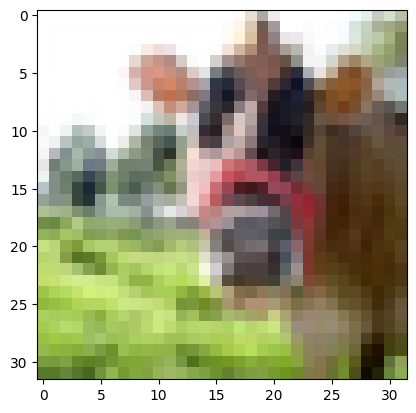

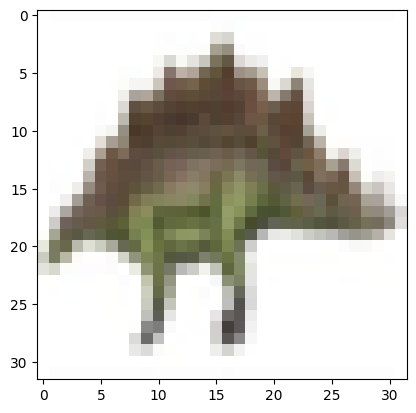

In [78]:
for i in range(0,2):
  plt.imshow(X_train2[i].reshape(32,32,3),cmap='gray')
  plt.show()

In [68]:
model_mnist_2 = keras.models.Sequential([
    keras.layers.Dense(128,activation = 'relu' , input_shape=(32*32*3,)),
    keras.layers.Dense(64,activation='relu'),
    keras.layers.Dense(100, activation='softmax')
])

In [69]:
model_mnist_2.compile(optimizer='adam',loss = 'sparse_categorical_crossentropy',metrics=['accuracy'])

In [70]:
model_mnist_2.fit(X_train2,y_train2,epochs=25,validation_data=(X_test2,y_test2))b

Epoch 1/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.0416 - loss: 4.3498 - val_accuracy: 0.0849 - val_loss: 3.9686
Epoch 2/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.0937 - loss: 3.9032 - val_accuracy: 0.0907 - val_loss: 3.9616
Epoch 3/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.1124 - loss: 3.8012 - val_accuracy: 0.1142 - val_loss: 3.8059
Epoch 4/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.1253 - loss: 3.7215 - val_accuracy: 0.1261 - val_loss: 3.7316
Epoch 5/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.1332 - loss: 3.6751 - val_accuracy: 0.1393 - val_loss: 3.6904
Epoch 6/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.1395 - loss: 3.6259 - val_accuracy: 0.1382 - val_loss: 3.6839
Epoch 7/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.1439 - loss: 3.5911 - val_accuracy: 0.1506 - val_loss: 3.6124
Epoch 8/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.1509 - loss: 3

In [71]:
test_loss,test_acc = model_mnist_2.evaluate(X_test2,y_test2)
print(f'accuracy : {test_acc:.4f} \nloss : {test_loss:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1669 - loss: 3.5131
accuracy : 0.1692 
loss : 3.5148


In [72]:
y_pred2 = model_mnist_2.predict(X_test2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [74]:
y_pred2[9999].argmax()

70

In [75]:
model_mnist_2.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                     │ (None, 128)                 │         393,344 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_34 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_35 (Dense)                     │ (None, 100)                 │           6,500 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,224,302 (4.67 MB)

 Trainable params: 408,100 (1.56 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 816,202 (3.11 MB)

In [76]:
for layer in model_mnist_1.layers:
  weights, biases = layer.get_weights()
  print(f"Weights : {weights}")
  print(f"Biases : {biases}")

Weights : [[-1.50622474e-02 -3.38420682e-02  2.64046311e-01 ... -2.46570725e-02
  -3.30617954e-03  8.27464089e-03]
 [-2.57096943e-02 -3.95448208e-02  3.48630488e-01 ...  1.57247614e-02
   2.60848515e-02  3.78553420e-02]
 [-2.08876319e-02  4.06813920e-02  3.43418121e-02 ... -4.36552195e-03
  -1.87904723e-02  2.12961752e-02]
 ...
 [-2.01275069e-02 -2.63512023e-02  1.92423359e-01 ... -3.22049186e-02
   2.85821389e-02  2.54321285e-02]
 [-3.93404625e-02  1.89010445e-02  1.36017665e-01 ...  2.15919642e-03
  -1.18575487e-02 -1.84526742e-02]
 [ 3.25450152e-02 -1.02175836e-04  3.51325601e-01 ... -5.54685155e-03
   1.60015970e-02 -1.64247379e-02]]
Biases : [-5.99940028e-03 -2.61115702e-03 -6.04384363e-01 -5.99645870e-03
 -4.40539652e-03 -5.88986138e-03 -6.00142777e-03 -7.75524834e-03
 -6.00487040e-03 -6.28686836e-03 -5.78280678e-03 -3.51190730e-03
 -6.11439254e-03  2.17078716e-01 -4.91134217e-03 -1.91926048e-03
 -6.00480195e-03 -7.17939867e-04 -5.98997483e-03 -6.00270461e-03
 -3.36730570e-01 -6.